In [114]:
from keras.datasets import reuters
from keras import models
from keras import layers
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

In [115]:
numWord = 10000
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=numWord)

/Users/ponlawatchangto/Desktop/VsCode/Mylearning/4312/.venv/lib/python3.13/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [116]:
print(f"len train_data : {len(train_data)}")
print(f"len test_data : {len(test_data)}")
print(f"train_data.shape : {train_data.shape}")
print(f"train_labels.shape : {train_labels.shape}")
print(train_data[0])

len train_data : 8982
len test_data : 2246
train_data.shape : (8982,)
train_labels.shape : (8982,)
[1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]


In [117]:
def vectorize_sequences(sequences, dimension=numWord):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1
    return results

In [118]:
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [119]:
one_hot_train_labels = to_categorical(train_labels)
one_hot_test_labels = to_categorical(test_labels)

In [120]:
print(x_train.shape)

(8982, 10000)


In [ ]:
model = models.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(numWord,)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(46, activation='softmax'))

model.compile(optimizer='rmsprop',
loss ='categorical_crossentropy',
metrics=['accuracy'])

/Users/ponlawatchangto/Desktop/VsCode/Mylearning/4312/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [122]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = one_hot_train_labels[:1000]
partial_y_train = one_hot_train_labels[1000:]

In [123]:
history = model.fit(
partial_x_train,
partial_y_train,
epochs=20,
batch_size=512,
validation_data=(x_val, y_val))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4652 - loss: 2.8369 - val_accuracy: 0.6100 - val_loss: 1.9599
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6560 - loss: 1.6365 - val_accuracy: 0.6820 - val_loss: 1.4303
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7330 - loss: 1.2385 - val_accuracy: 0.7270 - val_loss: 1.2232
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7846 - loss: 1.0101 - val_accuracy: 0.7680 - val_loss: 1.1021
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8211 - loss: 0.8442 - val_accuracy: 0.7750 - val_loss: 1.0350
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8522 - loss: 0.7053 - val_accuracy: 0.7880 - val_loss: 0.9791
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8752 - loss: 0.5958 - val_accuracy: 0.7980 - val_loss: 0.9452
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8955 - loss: 0.5029 - val_accuracy: 0.8050 - val_loss

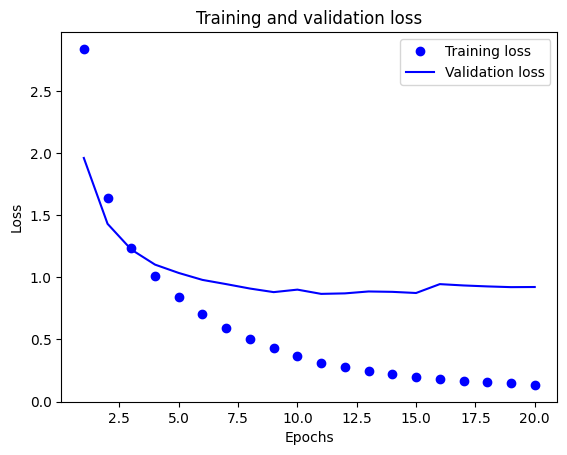

In [124]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

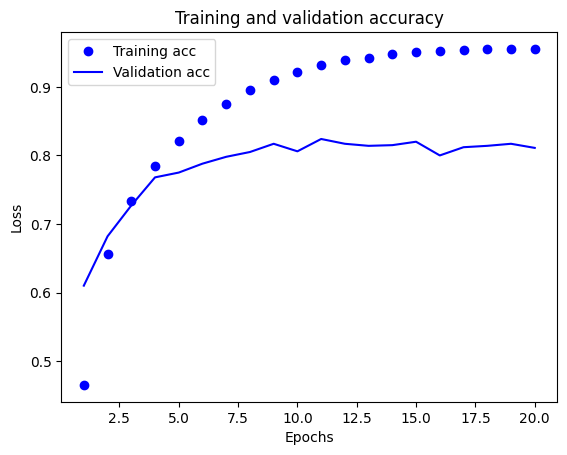

In [125]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.clf()
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [126]:
model = models.Sequential([
    layers.Dense(64,activation='relu',input_shape=(numWord,)),
    layers.Dense(64,activation='relu'),
    layers.Dense(46,activation='softmax')
])

model.compile(optimizer='rmsprop',
loss='binary_crossentropy',
metrics=['accuracy'])

history_binaryTest = model.fit(partial_x_train,partial_y_train,epochs=20,batch_size=512,validation_data=(x_val,y_val))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0054 - loss: 0.5036 - val_accuracy: 0.0020 - val_loss: 0.2676
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1567 - loss: 0.1769 - val_accuracy: 0.4150 - val_loss: 0.1187
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4159 - loss: 0.1014 - val_accuracy: 0.5300 - val_loss: 0.0892
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4954 - loss: 0.0822 - val_accuracy: 0.5070 - val_loss: 0.0765
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5207 - loss: 0.0719 - val_accuracy: 0.5350 - val_loss: 0.0678
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5382 - loss: 0.0646 - val_accuracy: 0.5500 - val_loss: 0.0616
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5690 - loss: 0.0594 - val_accuracy: 0.5830 - val_loss: 0.0572
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5956 - loss: 0.0555 - val_accuracy: 0.5960 - val_loss:

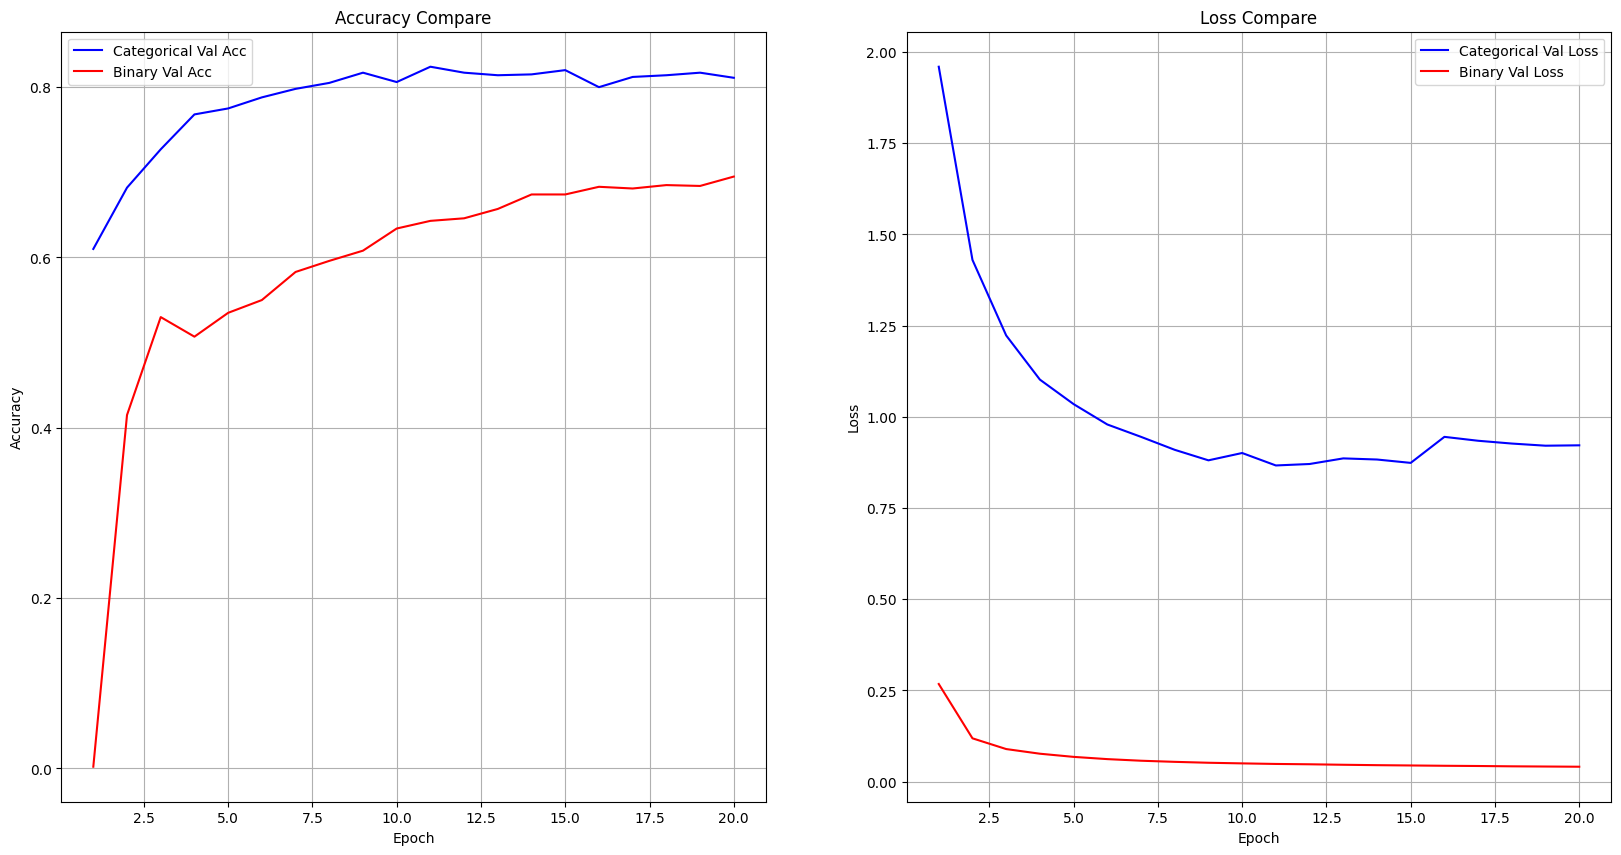

In [127]:
binary_val_loss = history_binaryTest.history['val_loss']
binary_val_acc = history_binaryTest.history['val_accuracy']

size = 10
plt.figure(figsize=(size*2,size))

plt.subplot(1,2,1)
plt.title('Accuracy Compare')
plt.grid(True)
plt.plot(epochs,val_acc,'b',label='Categorical Val Acc')
plt.plot(epochs,binary_val_acc,'r',label='Binary Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.title('Loss Compare')
plt.plot(epochs,val_loss,'b',label='Categorical Val Loss')
plt.plot(epochs,binary_val_loss,'r',label='Binary Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [128]:
model = models.Sequential()
model.add(layers.Dense(32, activation='relu', input_shape=(numWord,)))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(46, activation='softmax'))

model.compile(optimizer='rmsprop',
loss='categorical_crossentropy',
metrics=['accuracy'])

history_32N = model.fit(partial_x_train,partial_y_train,epochs=20,batch_size=512,validation_data=(x_val,y_val))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3180 - loss: 3.1195 - val_accuracy: 0.5370 - val_loss: 2.4111
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6056 - loss: 2.0264 - val_accuracy: 0.6270 - val_loss: 1.7445
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6810 - loss: 1.5270 - val_accuracy: 0.6770 - val_loss: 1.4424
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7245 - loss: 1.2586 - val_accuracy: 0.7090 - val_loss: 1.2753
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7592 - loss: 1.0813 - val_accuracy: 0.7360 - val_loss: 1.1708
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7899 - loss: 0.9449 - val_accuracy: 0.7410 - val_loss: 1.1127
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8133 - loss: 0.8316 - val_accuracy: 0.7520 - val_loss: 1.0807
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8375 - loss: 0.7352 - val_accuracy: 0.7780 - val_loss:

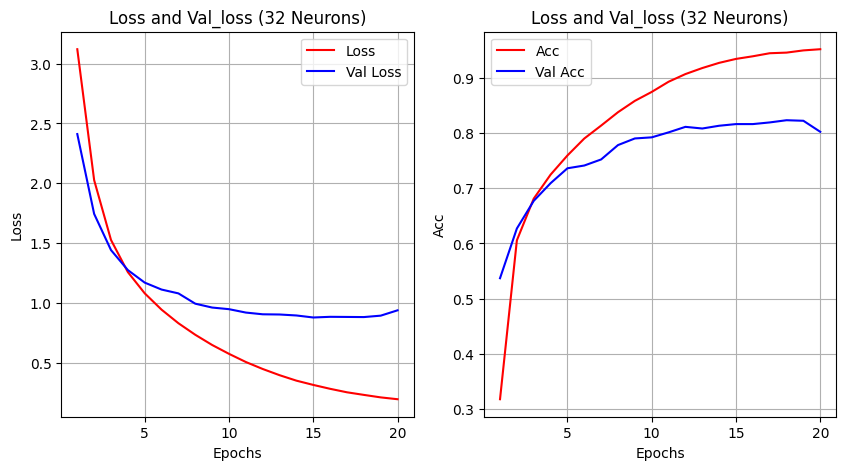

In [129]:
loss = history_32N.history['loss']
acc = history_32N.history['accuracy']
val_loss = history_32N.history['val_loss']
val_acc = history_32N.history['val_accuracy']
epochs = range(1,len(loss)+1)

size=5
plt.figure(figsize=(size*2,size))

plt.subplot(1,2,1)
plt.title('Loss and Val_loss (32 Neurons)')
plt.grid(True)
plt.plot(epochs,loss,'r',label='Loss')
plt.plot(epochs,val_loss,'b',label='Val Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.subplot(1,2,2)
plt.title('Loss and Val_loss (32 Neurons)')
plt.grid(True)
plt.plot(epochs,acc,'r',label='Acc')
plt.plot(epochs,val_acc,'b',label='Val Acc')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Acc')

plt.show()

In [130]:
model = models.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(numWord,)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(46, activation='sigmoid'))

model.compile(optimizer='rmsprop',
loss='categorical_crossentropy',
metrics=['accuracy'])

history_sigmoid = model.fit(partial_x_train,partial_y_train,epochs=20,batch_size=512,validation_data=(x_val,y_val))

Epoch 1/20


/Users/ponlawatchangto/Desktop/VsCode/Mylearning/4312/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4751 - loss: 2.9088 - val_accuracy: 0.6240 - val_loss: 1.9702
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6759 - loss: 1.6027 - val_accuracy: 0.7030 - val_loss: 1.3916
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7539 - loss: 1.1794 - val_accuracy: 0.7440 - val_loss: 1.2133
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7979 - loss: 0.9556 - val_accuracy: 0.7550 - val_loss: 1.0865
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8302 - loss: 0.7956 - val_accuracy: 0.7930 - val_loss: 1.0040
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8608 - loss: 0.6625 - val_accuracy: 0.8080 - val_loss: 0.9487
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8834 - loss: 0.5555 - val_accuracy: 0.8100 - val_loss: 0.9231
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9047 - loss: 0.4689 - val_accuracy: 0.8150 - val_loss: 0.8796
Ep

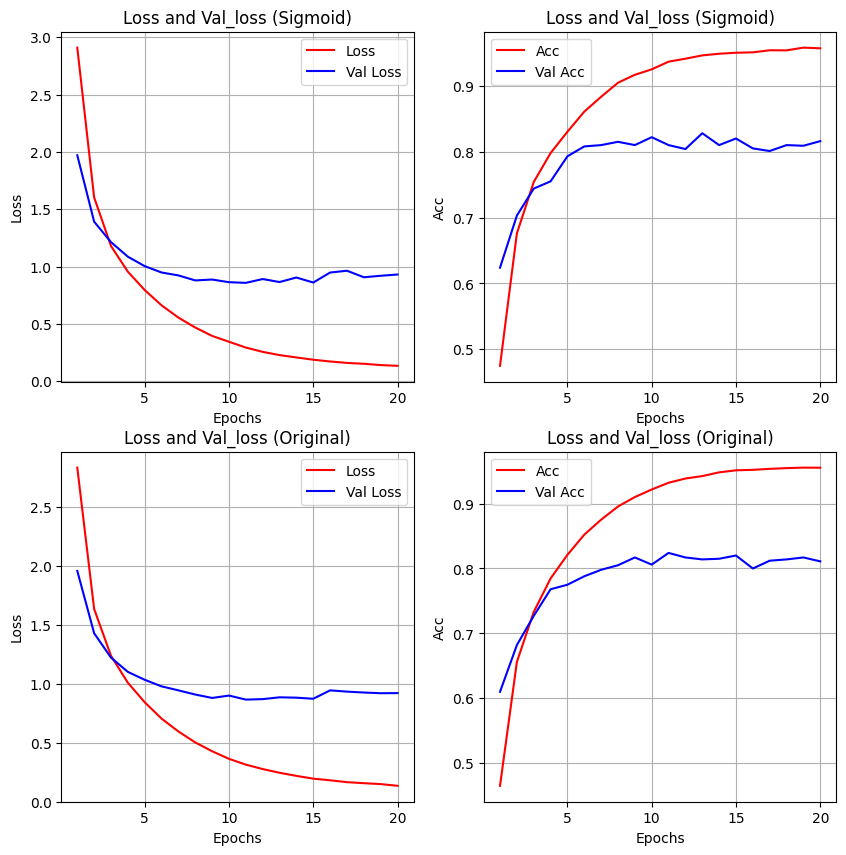

In [133]:
loss = history_sigmoid.history['loss']
acc = history_sigmoid.history['accuracy']
val_loss = history_sigmoid.history['val_loss']
val_acc = history_sigmoid.history['val_accuracy']
epochs = range(1,len(loss)+1)

size=5
plt.figure(figsize=(size*2,size*2))

plt.subplot(2,2,1)
plt.title('Loss and Val_loss (Sigmoid)')
plt.grid(True)
plt.plot(epochs,loss,'r',label='Loss')
plt.plot(epochs,val_loss,'b',label='Val Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.subplot(2,2,2)
plt.title('Loss and Val_loss (Sigmoid)')
plt.grid(True)
plt.plot(epochs,acc,'r',label='Acc')
plt.plot(epochs,val_acc,'b',label='Val Acc')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Acc')

loss = history.history['loss']
acc = history.history['accuracy']
val_loss = history.history['val_loss']
val_acc = history.history['val_accuracy']

plt.subplot(2,2,3)
plt.title('Loss and Val_loss (Original)')
plt.grid(True)
plt.plot(epochs,loss,'r',label='Loss')
plt.plot(epochs,val_loss,'b',label='Val Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.subplot(2,2,4)
plt.title('Loss and Val_loss (Original)')
plt.grid(True)
plt.plot(epochs,acc,'r',label='Acc')
plt.plot(epochs,val_acc,'b',label='Val Acc')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Acc')

plt.show()